# 주차 공간 탐지 및 인식을 위한 객체 탐지 프로젝트 #1

**- 목표: 대형주차장에서 주차 가능 공간과 주행 가능 공간을 판단하는 모델을 학습하기 위한 데이터 수집, 전처리**

## 1. 데이터 수집
- 예시 데이터셋 - [AIHUB] 주차 공간 탐색을 위한 차량 관점 복합 데이터
    - 링크: https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&dataSetSn=598
    - 자율주행차의 주차환경에서 주행 가능 영역 및 주차 공간 탐색을 훈련하기 위한 데이터 셋
    - 전체 502,375장의 이미지
- 다운로드 방법
    - 회원가입 - [다운로드] 클릭
    - 전체 데이터 중 2.Validation 데이터만 선택해서 다운로드 (약 36GB)
    - 36GB 전체를 다운받기 힘들다면 2.Validation의 {실내_대형주차장, 실내_중소형주차장, 실외_노상, 실외_대형주차장, 실외_일반도로, 실외_중소형주차장} 중 {실외_중소형주차장} 1개의 원천데이터와 라벨링데이터만 선택하여 다운로드
- 다운로드 받은 후 구글드라이브에 project/data/ 폴더 생성 후 .zip 파일 2개 업로드

###1-1. 구글 드라이브로 데이터 이전

In [ ]:
# 구글 드라이브 마운트
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# ls 명령어로 디렉토리 내부 파일 확인
# 아래 경로와 동일한 경로에 파일 위치시켜야 함
!ls /content/drive/MyDrive/project/data

VL6_실외_중소형주차장.zip  VS6_실외_중소형주차장.zip


In [2]:
# images와 labels 디렉토리 생성 - mkdir: make directory
!mkdir /content/drive/MyDrive/project/data/images
!mkdir /content/drive/MyDrive/project/data/labels

In [3]:
# VL로 시작하는 라벨 파일은 labels 디렉토리에, VS로 시작하는 이미지 파일은 images 디렉토리에 압축 해제
# 약 20분 정도 소요됨
!unzip -q '/content/drive/MyDrive/project/data/VL*.zip' -d /content/drive/MyDrive/project/data/labels
!unzip -q '/content/drive/MyDrive/project/data/VS*.zip' -d /content/drive/MyDrive/project/data/images

###1-2. 탐색적 데이터 분석(EDA)
- 전체 데이터 개수, 라벨링 타입 등 확인

전체 데이터 개수 확인  
=> 이미지 개수와 라벨 개수가 다름  
=> 전처리 과정에서 이미지와 라벨 쌍이 맞는 항목만 추출해야 함

In [4]:
# 특정 directory 하위의 전체 파일 개수를 반환하는 함수
import os

def count_files_in_directory(directory):
    total_files = 0
    for root, dirs, files in os.walk(directory):
        total_files += len(files)
    return total_files

In [5]:
img_dir = '/content/drive/MyDrive/project/data/images'
lbl_dir = '/content/drive/MyDrive/project/data/labels'

for dir in (img_dir, lbl_dir):
    print(f"{dir}: {count_files_in_directory(dir)}")

/content/drive/MyDrive/project/data/images: 20072
/content/drive/MyDrive/project/data/labels: 15543


이미지 확인을 위한 패키지 설치

In [7]:
!pip install matplotlib pillow opencv-python

In [8]:
# 샘플 이미지와 라벨 파일의 경로 설정
sample_img = 'data/images/실외/중소형주차장/중소형주차장_593-2/Camera/00000212.jpg'
sample_lbl = 'data/labels/실외/중소형주차장/중소형주차장_593-2/label/00000212.json'

1920 1080


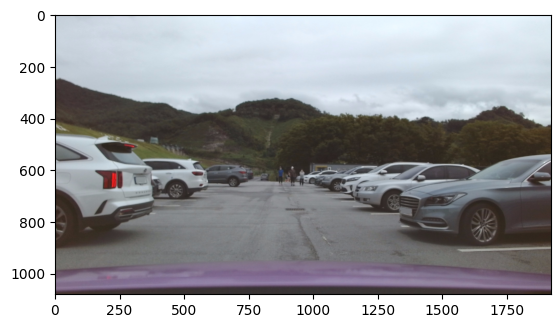

In [9]:
# 이미지 출력 및 사이즈 확인
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = cv2.imread(sample_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
height, width, _ = img.shape

plt.imshow(img)
print(width, height)

라벨 json 파일 확인

In [10]:
import json

with open(sample_lbl, 'r') as f:
    data = json.load(f)

print(data)

{'image': 'Camera/ 00000212 .jpg', 'point_cloud': 'LiDAR/ 00000212 .pcd', 'meta': {'time': 'Day', 'environment': 'Outdoor', 'weather': 'Sunny', 'place': 'Small and Medium', 'city': 'Gwangju', 'terrain': 'Urban', 'road_type': 'ge 4m', 'road_material': 'Paved'}, 'calib': {'intrinsic': [[1397.991371, 0.0, 960.0], [0.0, 1397.991371, 540.0], [0.0, 0.0, 1.0]], 'rotation': [-0.96517669, -1.502906215, 2.560259924], 'translation': [0.13620099, 1.34389899, 1.35197656]}, 'bbox2d': [{'name': 'Car', 'occluded': False, 'bbox': [734.83, 593.94, 767.14, 638.59], 'status': 'Parked'}, {'name': 'Car', 'occluded': False, 'bbox': [794.01, 615.0, 825.23, 643.68], 'status': 'Parked'}, {'name': 'Car', 'occluded': False, 'bbox': [1324.8, 541.0, 1920.0, 894.39], 'status': 'Parked'}, {'name': 'Car', 'occluded': True, 'bbox': [1150.4, 577.64, 1647.83, 764.3], 'status': 'Parked'}, {'name': 'Car', 'occluded': True, 'bbox': [1100.4, 568.78, 1459.2, 707.4], 'status': 'Parked'}, {'name': 'Car', 'occluded': True, 'bbox

이미지에 라벨(폴리곤) 그려보기(1)  
=> 색 구분을 하지 않아 공간을 구분하기 어려움

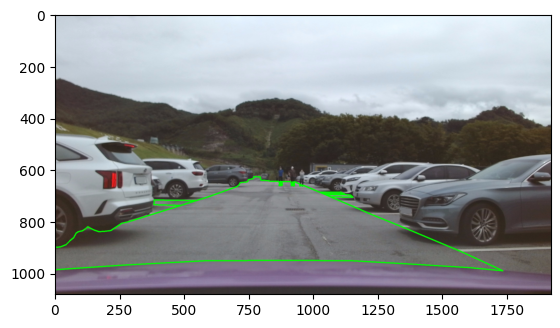

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_polygon(img, points):
    cv2.polylines(img, [points], isClosed=True, color=(0, 255, 0), thickness=3)


img = cv2.imread(sample_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

with open(sample_lbl, 'r') as f:
    data = json.load(f)

for item in data['segmentation']:
    points = np.array(item['polygon'], np.int32).reshape((-1, 1, 2))
    draw_polygon(img, points)

# 결과 이미지 보기
plt.imshow(img)

이미지에 라벨(폴리곤) 그려보기(2)
- 주행 가능 공간(Driveable Space)는 초록색
- 그 외(주차 가능 공간)는 노란색

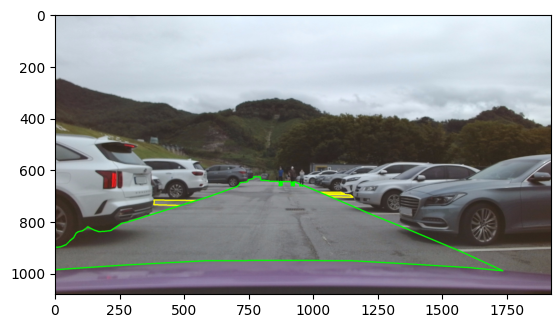

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_polygon(img, p_type, points):
    # 폴리곤 색 설정
    if p_type == 'Driveable Space':
        color = (0, 255, 0) # 초록색
    else:
        color = (255, 255, 0) # 노란색
    cv2.polylines(img, [points], isClosed=True, color=color, thickness=3)

img = cv2.imread(sample_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

with open(sample_lbl, 'r') as f:
    data = json.load(f)

for item in data['segmentation']:
    p_type = item['name']
    points = np.array(item['polygon'], np.int32).reshape((-1, 1, 2))
    draw_polygon(img, p_type, points)

# 결과 이미지 보기
plt.imshow(img)

segmentation이 있는 라벨 파일 개수 확인
- 전체 라벨 중 bbox가 아닌 segmentation만 사용할 예정
- segmentation 파일이 적으면 학습이 어렵기 때문에 미리 확인

In [13]:
# 약 6분 정도 소요됨
import os
import json

def check_lbl(lbl_dir, target='segmentation'):
    total_files = 0

    for item in os.listdir(lbl_dir): # listdir 함수는 lbl_dir 하위 모든 폴더와 파일 리스트를 반환
        item_path = os.path.join(lbl_dir, item)

        if os.path.isdir(item_path): # item이 디렉토리면 재귀호출
            total_files += check_lbl(item_path)
        elif os.path.isfile(item_path): # item이 파일이면 json file read하여 라벨 확인
            with open(item_path, 'r') as f:
                data = json.load(f)
                if data[target]: # data[target]이 빈 리스트가 아니면 카운트 +1
                    total_files += 1

    return total_files

total_segment_files = check_lbl(lbl_dir)
print(total_segment_files)

7875


## 2.데이터 전처리
- 조건1. segmentation 내용이 있어야 함
- 조건2. image와 label 쌍이 맞아야 함

###2-1. segmentation 라벨이 없는 파일 삭제

In [14]:
# seg_images와 seg_labels 디렉토리 생성
!mkdir data/seg_images
!mkdir data/seg_labels

In [15]:
img_dir = 'data/images'
lbl_dir = 'data/labels'

In [16]:
# 약 8분 정도 소요
import os
import json

def check_lbl(lbl_dir, target='segmentation'):
    for item in os.listdir(lbl_dir): # listdir 함수는 lbl_dir 하위 모든 폴더와 파일 리스트를 반환
        item_path = os.path.join(lbl_dir, item)

        if os.path.isdir(item_path): # item이 디렉토리면 재귀호출
            check_lbl(item_path)
        elif os.path.isfile(item_path): # item이 파일이면 json file read하여 라벨 확인
            with open(item_path, 'r') as f:
                data = json.load(f)
            if not data[target]: # data[target]이 빈 리스트면 라벨과 이미지 파일 삭제
                try:
                    os.remove(item_path) # 라벨
                    img_path = item_path.replace('labels', 'images').replace('label','Camera').replace('json', 'jpg')
                    os.remove(img_path)
                except:
                    print('error')

check_lbl(lbl_dir)

삭제 후 데이터 개수 확인

In [17]:
# 특정 directory 하위의 전체 파일 개수를 반환하는 함수
import os

def count_files_in_directory(directory):
    total_files = 0
    for root, dirs, files in os.walk(directory):
        total_files += len(files)
    return total_files

In [18]:
for dir in {img_dir, lbl_dir}:
    print(f"{dir}: {count_files_in_directory(dir)}")

data/images: 12404
data/labels: 7875


###2-2. 라벨이 없는 이미지 삭제

In [19]:
import os
import json

def check_img(img, target='segmentation'):
    for item in os.listdir(img): # listdir 함수는 img 하위 모든 폴더와 파일 리스트를 반환
        item_path = os.path.join(img, item)

        if os.path.isdir(item_path): # item이 디렉토리면 재귀호출
            check_img(item_path)
        elif os.path.isfile(item_path): # item이 파일이면 라벨이 있는지 확인
            lbl_path = item_path.replace('images','labels').replace('Camera','label').replace('.jpg','.json')
            if not os.path.isfile(lbl_path):
                try:
                    os.remove(item_path)
                    print(item_path)
                except:
                    print('error')

check_img(img_dir)

data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000021.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000017.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000016.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000002.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000040.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000023.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000051.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000025.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000061.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000029.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000050.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000036.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000008.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000028.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000053.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000020.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000043.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000045.pcd
data/images/실외/중소형주차장/중소형주차장_618/LiDAR/00000032.pcd
data/images/

In [20]:
for dir in {img_dir, lbl_dir}:
    print(f"{dir}: {count_files_in_directory(dir)}")

data/images: 7875
data/labels: 7875


## 3. train/validation/test set을 8:1:1로 분리
- train => 모델 훈련에 사용
- val => 모델 훈련 과정에서 중간 평가용으로 사용
- test => 모델 훈련을 마친 후 최종 평가용으로 사용

파일명 통합

In [21]:
# 전체 이미지 파일 이름 수정(중복되지 않게) 및 한 곳으로 통합
import os
import shutil

def rename_and_copy_images(src_dir, dst_dir, target='.jpg', rm_name=''):
    """
    src_dir: 기존 이미지가 저장된 디렉토리
    dst_dir: 새로운 이미지가 저장될 디렉토리
    target: 타겟 파일 형식
    rm_name: 해당 문자열이 파일명에 포함된 경우, 문자열 부분 삭제
    """
    # dst_dir이 없으면 생성
    if not os.path.exists(dst_dir):
        os.makedirs(dst_dir)

    # Traverse the source directory
    for root, _, files in os.walk(src_dir):
        for file in files:
            if file.lower().endswith(target):  # target 타입의 파일이면
                # 새로운 이름 생성
                relative_path = os.path.relpath(os.path.join(root, file), src_dir)
                new_name = relative_path.replace(os.sep, '_').replace(rm_name, '') # 필요없는 이름 삭제

                # 새로운 경로
                dst_file_path = os.path.join(dst_dir, new_name)
                os.makedirs(os.path.dirname(dst_file_path), exist_ok=True)

                # 파일 복사
                shutil.copy2(os.path.join(root, file), dst_file_path)

In [22]:
# 이미지 파일 이름 수정 - src_dir 하위 이미지 파일들 이름 수정 후 dst_dir에 저장
src_dir= 'data/images'
dst_dir = 'data/sum_images'

rename_and_copy_images(src_dir, dst_dir, '.jpg', '_Camera') # _Camera 부분은 필요없으므로 삭제

In [23]:
# 라벨 파일 이름 수정 - src_dir 하위 라벨 파일들 이름 수정 후 dst_dir에 저장
src_dir= 'data/labels'
dst_dir = 'data/sum_labels'

# 중간에 의미 없는 label_ 이름은 삭제
rename_and_copy_images(src_dir, dst_dir, '.json', 'label_') # label_ 부분은 필요없으므로 삭제

In [24]:
# 이미지와 라벨 개수 확인
print(len(os.listdir('data/sum_images')))
print(len(os.listdir('data/sum_labels')))

7875
7875


train/validation/test set 8:1:1로 분할
- sklearn 패키지 사용

In [ ]:
     # 필요한 라이브러리 import
import os  # 파일 및 디렉토리 작업을 위한 라이브러리
import shutil  # 파일 복사를 위한 라이브러리
from sklearn.model_selection import train_test_split  # 데이터셋 분할을 위한 함수

# 원본 이미지와 라벨 파일이 저장된 디렉토리 경로 설정
img_dir = '/content/drive/MyDrive/project/data/sum_images'  # 통합된 이미지 파일들이 있는 디렉토리
lbl_dir = '/content/drive/MyDrive/project/data/sum_labels'  # 통합된 라벨 파일들이 있는 디렉토리

# 분할된 데이터를 저장할 경로 설정
# train 세트: 모델 학습에 사용될 데이터 (80%)
train_image_dir = '/content/drive/MyDrive/project/dataset/train/images'  # 학습용 이미지 저장 경로
train_label_dir = '/content/drive/MyDrive/project/dataset/train/labels'  # 학습용 라벨 저장 경로

# validation 세트: 학습 중간 평가에 사용될 데이터 (10%)
val_image_dir = '/content/drive/MyDrive/project/dataset/val/images'  # 검증용 이미지 저장 경로
val_label_dir = '/content/drive/MyDrive/project/dataset/val/labels'  # 검증용 라벨 저장 경로

# test 세트: 최종 평가에 사용될 데이터 (10%)
test_image_dir = '/content/drive/MyDrive/project/dataset/test/images'  # 테스트용 이미지 저장 경로
test_label_dir = '/content/drive/MyDrive/project/dataset/test/labels'  # 테스트용 라벨 저장 경로

# 폴더가 존재하지 않으면 생성
# exist_ok=True: 폴더가 이미 존재해도 에러를 발생시키지 않음
os.makedirs(train_image_dir, exist_ok=True)  # 학습용 이미지 디렉토리 생성
os.makedirs(val_image_dir, exist_ok=True)  # 검증용 이미지 디렉토리 생성
os.makedirs(test_image_dir, exist_ok=True)  # 테스트용 이미지 디렉토리 생성

os.makedirs(train_label_dir, exist_ok=True)  # 학습용 라벨 디렉토리 생성
os.makedirs(val_label_dir, exist_ok=True)  # 검증용 라벨 디렉토리 생성
os.makedirs(test_label_dir, exist_ok=True)  # 테스트용 라벨 디렉토리 생성

# 이미지와 라벨 파일 리스트 가져오기
# sorted()를 사용하여 파일명 순서대로 정렬 (이미지와 라벨의 인덱스가 일치하도록 보장)
images = sorted(os.listdir(img_dir))  # 원본 이미지 디렉토리의 모든 파일명을 정렬하여 리스트로 저장
labels = sorted(os.listdir(lbl_dir))  # 원본 라벨 디렉토리의 모든 파일명을 정렬하여 리스트로 저장

# 데이터셋 분할
# 1단계: 전체 데이터를 train(80%)과 temp(20%)로 분할
# test_size=0.2: 전체 데이터의 20%를 temp로 분리 (나머지 80%는 train)
# random_state=42: 동일한 시드값으로 분할하여 재현 가능한 결과 보장
# images와 labels를 함께 분할하여 이미지-라벨 쌍이 유지되도록 함
train_images, temp_images, train_labels, temp_labels = train_test_split(images, labels, test_size=0.2, random_state=42) # train:temp = 8:2

# 2단계: temp 데이터(20%)를 validation(10%)과 test(10%)로 분할
# test_size=0.5: temp 데이터의 50%를 test로 분리 (나머지 50%는 validation)
# 최종적으로 전체 데이터의 10%씩 validation과 test로 분할됨
val_images, test_images, val_labels, test_labels = train_test_split(temp_images, temp_labels, test_size=0.5, random_state=42) # val:test = 1:1

# 파일 복사 함수 정의
# file_list: 복사할 파일명 리스트
# src_dir: 원본 파일이 있는 디렉토리
# dst_dir: 파일을 복사할 대상 디렉토리
def copy_files(file_list, src_dir, dst_dir):
    # 리스트의 각 파일명에 대해 반복
    for file_name in file_list:
        # 원본 파일 경로와 대상 파일 경로를 결합하여 파일 복사
        shutil.copy(os.path.join(src_dir, file_name), os.path.join(dst_dir, file_name))

# 파일 복사 실행
# train 세트 복사
print('train')  # 진행 상황 출력
copy_files(train_images, img_dir, train_image_dir)  # 학습용 이미지 파일 복사
copy_files(train_labels, lbl_dir, train_label_dir)  # 학습용 라벨 파일 복사

# validation 세트 복사
print('val')  # 진행 상황 출력
copy_files(val_images, img_dir, val_image_dir)  # 검증용 이미지 파일 복사
copy_files(val_labels, lbl_dir, val_label_dir)  # 검증용 라벨 파일 복사

# test 세트 복사
print('test')  # 진행 상황 출력
copy_files(test_images, img_dir, test_image_dir)  # 테스트용 이미지 파일 복사
copy_files(test_labels, lbl_dir, test_label_dir)  # 테스트용 라벨 파일 복사

train
val
test


In [26]:
# train/val/test set 개수 확인
print(f"train: {len(os.listdir('dataset/train/images'))}")
print(f"val: {len(os.listdir('dataset/val/images'))}")
print(f"test: {len(os.listdir('dataset/test/images'))}")

train: 6300
val: 787
test: 788
